In [1]:
from xrss.dataloader import XRayDataset, show_images_and_bboxes
from xrss.old_models import ImprovedPixelTemplateMatching

# Model Initialization and qualitative testing (too long to run compared to the gained performance)

In [2]:
yaml_file = "../xray_data/data.yaml"

train_dataset = XRayDataset(yaml_file, split="train", resize=False)
val_dataset = XRayDataset(yaml_file, split="val", resize=False)

In [3]:
model = detector = ImprovedPixelTemplateMatching(
    threshold=0.90,
    max_templates_per_class=300,
    nms_threshold=0.2,
    scale_range=(0.6, 1.4),
    scale_steps=3,
    rotation_angles=[0, 45, 90, 135, 180],
    use_edge_matching=True,
    template_quality_threshold=0.15,
    custom_threshold={1: 0.95, 5: 0.95},
)
model.train(train_dataset)

Extracting up to 300 templates per class from 4200 images.
Using edge-based matching: True


Extracting templates:  41%|████      | 1707/4200 [00:03<00:04, 545.50it/s]


Training complete.
Class 0: 300 templates (avg quality: 0.226)
Class 1: 300 templates (avg quality: 0.251)
Class 2: 300 templates (avg quality: 0.280)
Class 3: 300 templates (avg quality: 0.277)
Class 4: 300 templates (avg quality: 0.300)
Class 5: 300 templates (avg quality: 0.309)


Displaying sample images with ground truth bounding boxes:


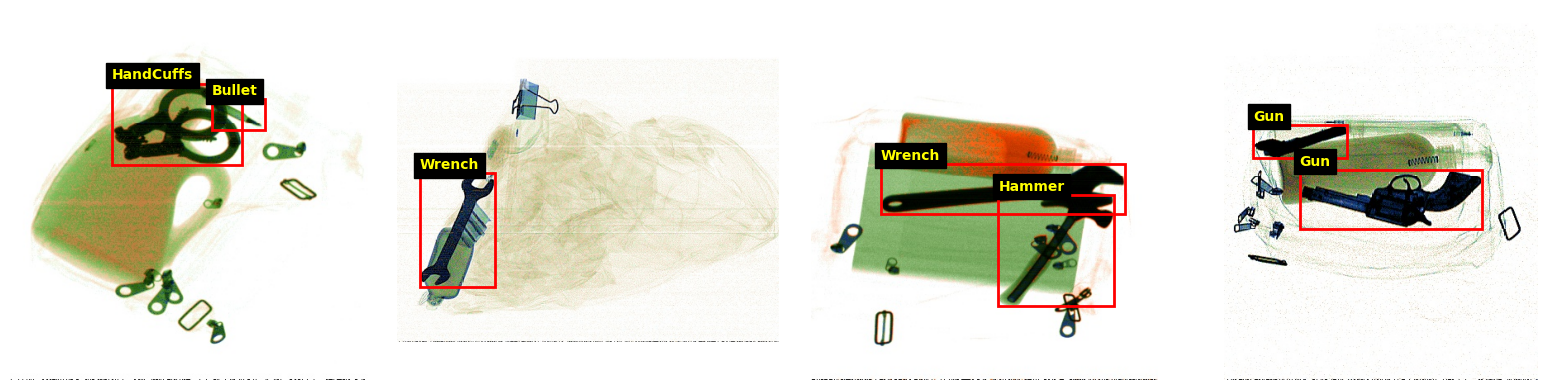

Displaying sample images with predicted bounding boxes:


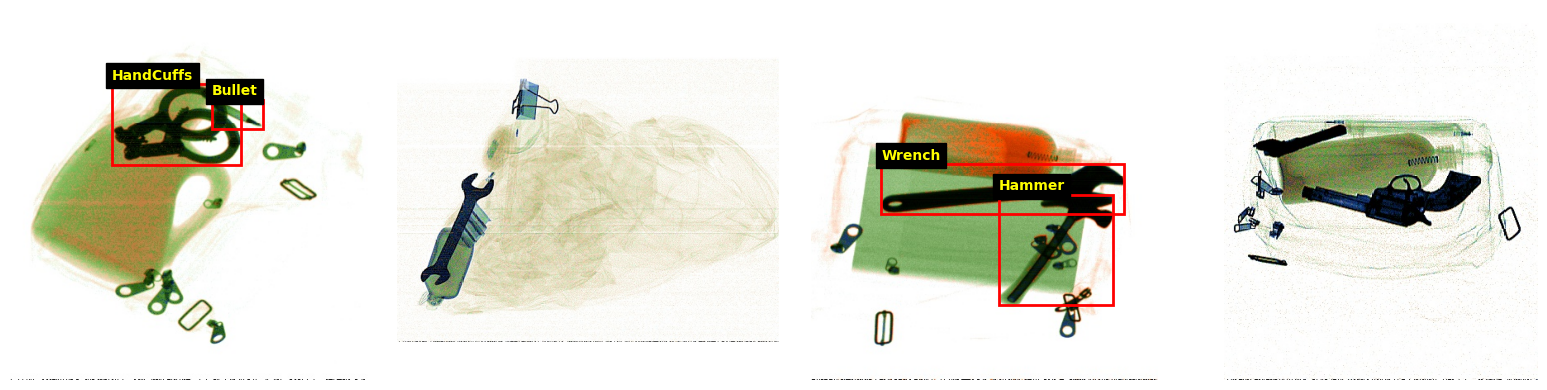

In [4]:
indexes = list(range(1, 5))

images = [val_dataset[i][0] for i in indexes]
labels = [val_dataset[i][1] for i in indexes]

print("Displaying sample images with ground truth bounding boxes:")
show_images_and_bboxes(val_dataset, images, labels, cols=4)

preds = []
for img in images:
    preds.append(model.detect(img))

print("Displaying sample images with predicted bounding boxes:")
show_images_and_bboxes(val_dataset, images, preds, cols=4)